In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv(r'S:\CodeDB\Solutions\Kaggle\titanic\train.csv')
test = pd.read_csv(r'S:\CodeDB\Solutions\Kaggle\titanic\test.csv')
PassengerId = test['PassengerId']
all_data = pd.concat([train, test], ignore_index=True)

In [2]:
# 效果等同于上面的多条件筛选
# train.query('Sex=="male"')

In [3]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


<Axes: xlabel='Sex', ylabel='Survived'>

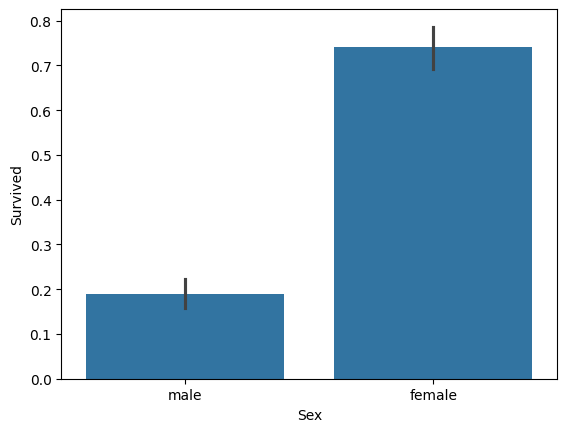

In [6]:
train
import matplotlib.pyplot as plt
df=train['Survived'].value_counts()
df
sns.barplot(x="Sex", y="Survived", data=train)
# 女性存活率更高

<Axes: xlabel='Pclass', ylabel='Survived'>

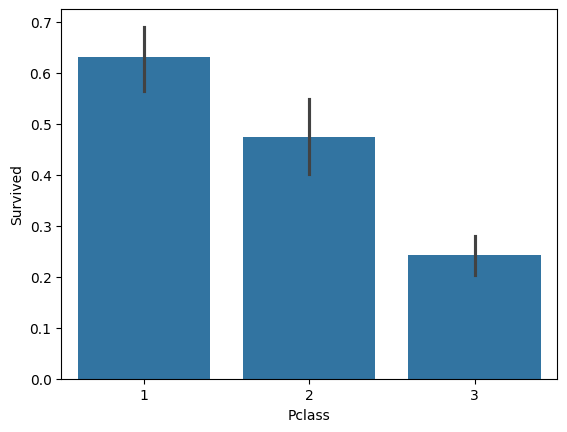

In [7]:
sns.barplot(x='Pclass',y='Survived',data=train)
# 舱位级别越高，存活率越高

<Axes: xlabel='SibSp', ylabel='Survived'>

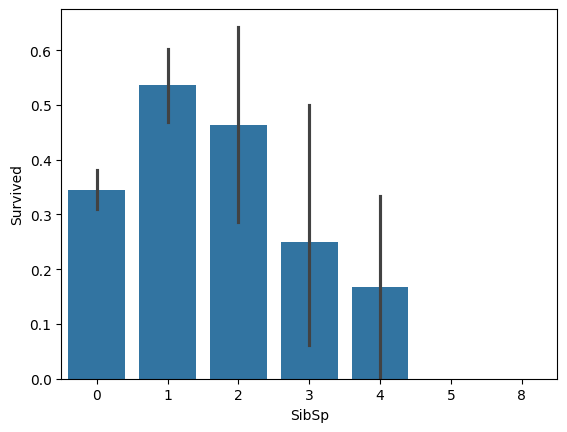

In [8]:
sns.barplot(x="SibSp", y="Survived", data=train)
# 兄弟姐妹数量

<Axes: xlabel='Parch', ylabel='Survived'>

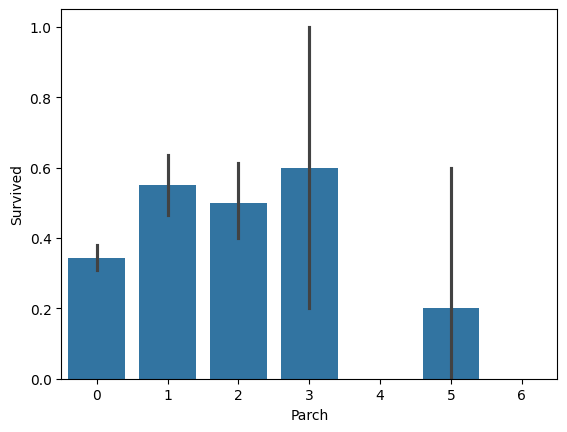

In [9]:
sns.barplot(x="Parch", y='Survived', data=train)
# 父母与小孩的个数

Text(672.6216036522636, 0.5, 'density')

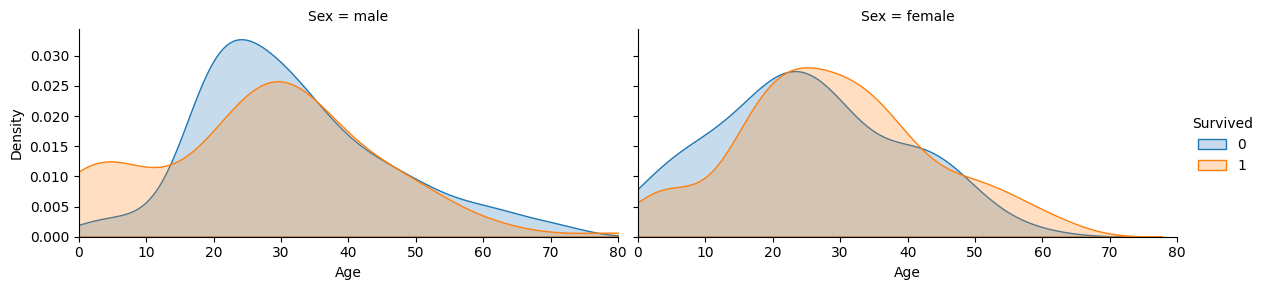

In [10]:
facet = sns.FacetGrid(data=train, hue='Survived',col='Sex', aspect=2)
facet.map(sns.kdeplot, 'Age',shade=True)
facet.set(xlim=(0, train['Age'].max()))
facet.add_legend()        # 添加图例（告诉你哪种颜色代表生还，哪种代表遇难）
plt.xlabel('Age')         # 设置 X 轴标签为“年龄”
plt.ylabel('density')     # 设置 Y 轴标签为“密度”


<Axes: title={'center': 'Embarked = Q'}, xlabel='Survived', ylabel='count'>

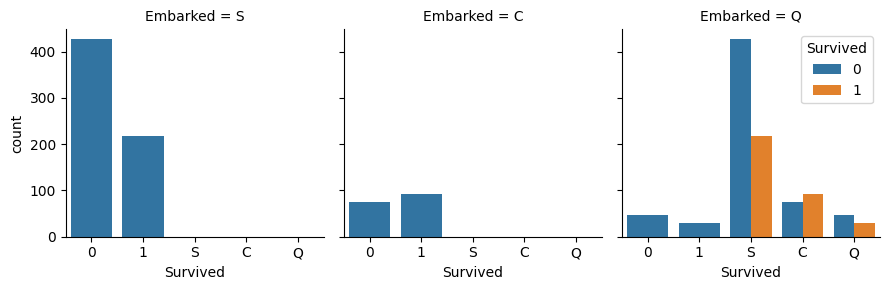

In [11]:
facet=sns.FacetGrid(data=train,col='Embarked')
facet.map(sns.countplot, 'Survived' )
sns.countplot(data=train, x='Embarked', hue='Survived')

In [12]:
train.groupby(['Embarked'])[['Pclass']].count()

,Pclass
Embarked,
C,168
Q,77
S,644


<Axes: xlabel='Title', ylabel='Survived'>

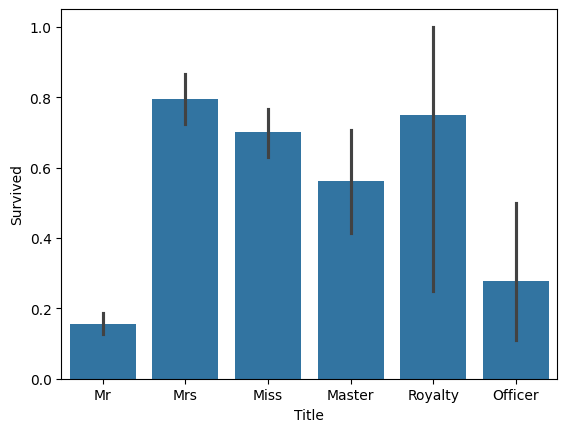

In [13]:
train['Title'] = train['Name'].apply(lambda x:x.split(',')[1].split('.')[0].strip())
Title_Dict = {}
Title_Dict.update(dict.fromkeys(['Capt', 'Col', 'Major', 'Dr', 'Rev'], 'Officer'))
Title_Dict.update(dict.fromkeys(['Don', 'Sir', 'the Countess', 'Dona', 'Lady'], 'Royalty'))
Title_Dict.update(dict.fromkeys(['Mme', 'Ms', 'Mrs'], 'Mrs'))
Title_Dict.update(dict.fromkeys(['Mlle', 'Miss'], 'Miss'))
Title_Dict.update(dict.fromkeys(['Mr'], 'Mr'))
Title_Dict.update(dict.fromkeys(['Master','Jonkheer'], 'Master'))

train['Title'] = train['Title'].map(Title_Dict)
sns.barplot(x="Title", y="Survived", data=train)

<Axes: xlabel='FamilySize', ylabel='Survived'>

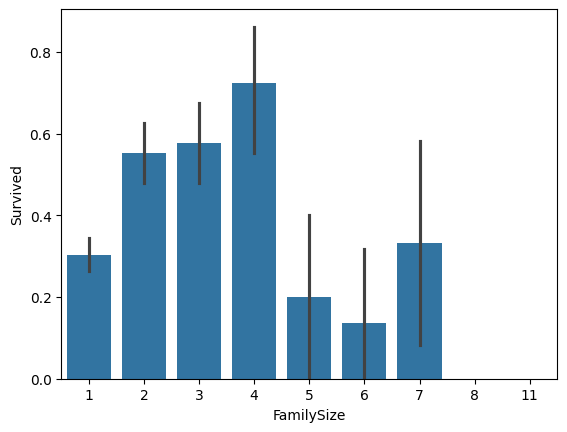

In [14]:
all_data['FamilySize']=all_data['SibSp']+all_data['Parch']+1
sns.barplot(x="FamilySize", y="Survived", data=all_data)

<Axes: xlabel='FamilySize', ylabel='Survived'>

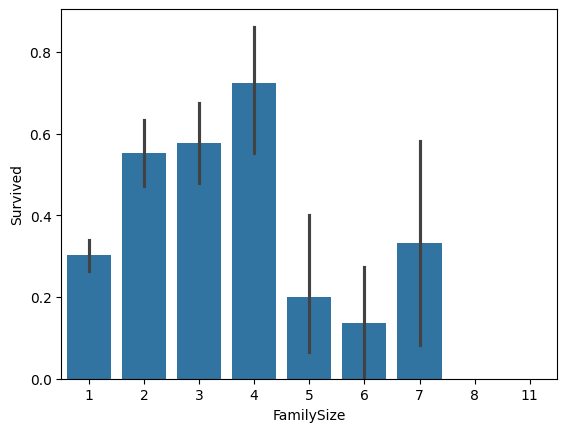

In [15]:
train['FamilySize']=train['SibSp']+train['Parch']+1
sns.barplot(data=train,x='FamilySize',y='Survived')